In [ ]:

                                                                         Addis Ababa University

                                                            Data science and Cloud computing for Bioinformatics

                                                                             Assignment 4

                                                                     Exploratory RNA-seq Data Analysis


                                                            Practical Assignment IV:Exploratory RNA-seq Data Analysis
 
                                                                           
                                                Data source:GSE52778 FPKM expression dataset and metadata from Module 3 assignments

                                                                        Student Name: Beyene Chalchisa


                                                                                 ID NO: GSR/4596/18


In [ ]:
Input data:lon Expression data
Metadata: your s_meta DataFrame 

In [28]:

#1–5. Load, validate, and basic QC
#1. Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load expression data
import pandas as pd

expression_long = pd.read_csv(r"C:\Users\user\project\results\tables\expression_long.csv",
    sep=",")

print("Expression shape:", expression_long.shape)
print(expression_long.columns.tolist())

display(expression_long.head())

Expression shape: (372368, 4)
['Sample_ID', 'Condition', 'Gene', 'Expression']


,Sample_ID,Condition,Gene,Expression
0,Dex_LL14,Dexamethasone,1/2-SBSRNA4,0.712995
1,Dex_LL06,Dexamethasone,1/2-SBSRNA4,0.440208
2,Dex_LL02,Dexamethasone,1/2-SBSRNA4,0.339547
3,Dex_LL10,Dexamethasone,1/2-SBSRNA4,0.392459
4,Alb_LL07,Albuterol,1/2-SBSRNA4,0.576075


In [29]:
# 2. Validate sample identifiers
print("Number of samples:")
print(expression_long["Sample_ID"].nunique())

print("\nSample IDs:")
print(expression_long["Sample_ID"].unique())

print("\nConditions:")
print(expression_long["Condition"].value_counts())

Number of samples:
16

Sample IDs:
['Dex_LL14' 'Dex_LL06' 'Dex_LL02' 'Dex_LL10' 'Alb_LL07' 'Alb_LL03'
 'Alb_LL11' 'Alb_LL15' 'Untreated_LL09' 'Untreated_LL05' 'Untreated_LL13'
 'Untreated_LL01' 'Alb_Dex_LL08' 'Alb_Dex_LL04' 'Alb_Dex_LL12'
 'Alb_Dex_LL16']

Conditions:
Condition
Dexamethasone              93092
Albuterol                  93092
Untreated                  93092
Albuterol_Dexamethasone    93092
Name: count, dtype: int64


In [30]:

#3. Check missing values and duplicates

print("Missing values per column:")
print(expression_long.isnull().sum())
print("\nTotal missing values:")
print(expression_long.isnull().sum().sum())
print("\nDuplicate rows:")
print(expression_long.duplicated().sum())
print("\nDuplicate Sample-Gene combinations:")
print( expression_long.duplicated(subset=["Sample_ID", "Gene"]).sum())

Missing values per column:
Sample_ID     0
Condition     0
Gene          0
Expression    0
dtype: int64

Total missing values:
0

Duplicate rows:
0

Duplicate Sample-Gene combinations:
16


In [31]:
print(expression_long["Expression"].dtype)

object


In [32]:
#Convert Expression to numeric
expression_long["Expression"] = pd.to_numeric(
    expression_long["Expression"],
    errors="coerce")
print(expression_long["Expression"].dtype)

float64


In [33]:
#conversion created missing values. so chech it.
print("Missing Expression values:")
print(expression_long["Expression"].isna().sum())

Missing Expression values:
3620


In [34]:

#If needed, let replace missing expression values with 0

expression_long["Expression"] = (expression_long["Expression"].fillna(0))

In [35]:

#5. Calculate detected genes

detected_genes = (
    expression_long
    .query("Expression > 0")
    .groupby("Sample_ID")["Gene"]
    .nunique()
    .sort_values())
print("Detected genes per sample:")
print(detected_genes)

Detected genes per sample:
Sample_ID
Alb_Dex_LL16      14261
Alb_Dex_LL04      17042
Untreated_LL01    17088
Dex_LL02          17094
Alb_LL03          17147
Alb_LL11          17306
Alb_LL15          17331
Alb_Dex_LL12      17345
Alb_Dex_LL08      17370
Untreated_LL09    17373
Dex_LL10          17387
Dex_LL14          17416
Untreated_LL05    17420
Dex_LL06          17461
Untreated_LL13    17468
Alb_LL07          17504
Name: Gene, dtype: int64


In [36]:
#know missing expression is will 0 after gene dectatacting
print(expression_long["Expression"].isna().sum())

0


Original data shape: (23273, 41)

First 10 columns:
['gene_id', 'tracking_id', 'class_code', 'nearest_ref_id', 'gene_short_name', 'tss_id', 'locus', 'length', 'coverage', 'Dex_FPKM']

All 16 sample columns were found.

Expression matrix shape: (23273, 17)
expression_long shape: (372368, 3)

First 5 rows of expression_long:
       gene_id Sample_ID  Expression
0  1/2-SBSRNA4  Dex_LL14    0.712995
1         A1BG  Dex_LL14    4.485040
2     A1BG-AS1  Dex_LL14    1.723240
3         A1CF  Dex_LL14    0.000000
4       "A2LD1  Dex_LL14    2.178160

Missing expression values:
3620


C:\Users\user\AppData\Local\Temp\ipykernel_9296\2926842453.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data,


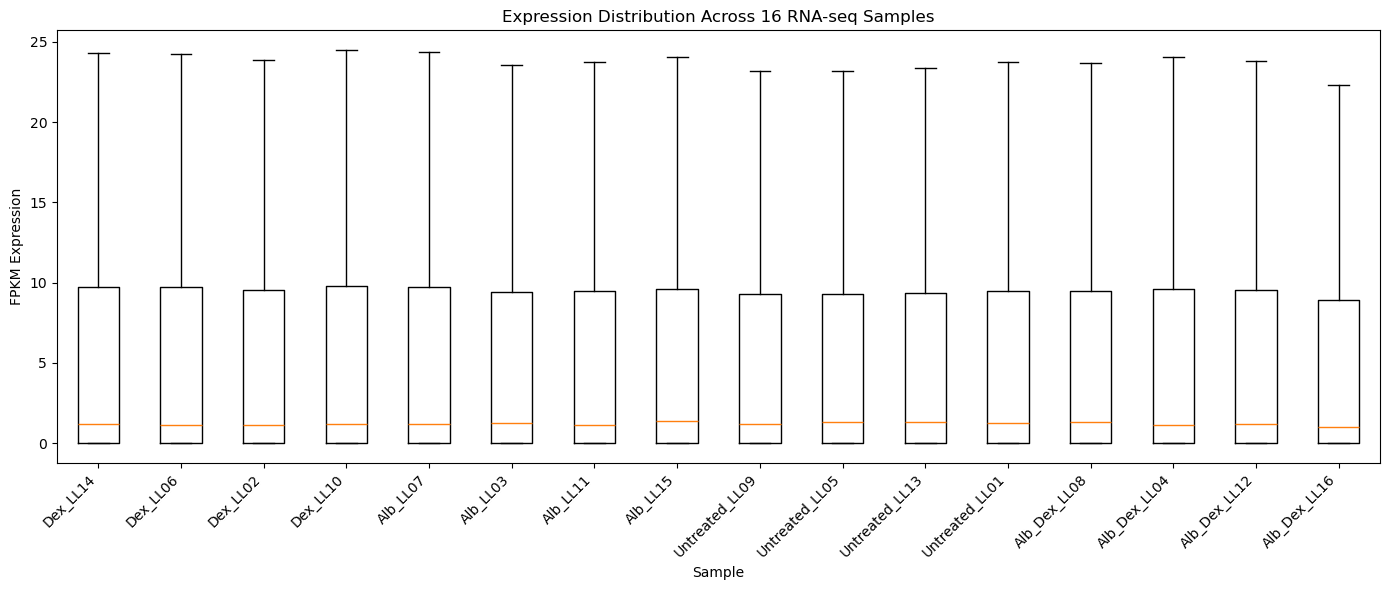

In [11]:
# 6. Plot sample expression distributions
# Corrected: the FPKM file is whitespace-separated

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Load the FPKM file correctly


file_path = r"C:\Users\user\project\data\processed\GSE52778_All_Sample_FPKM_Matrix.txt"

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    engine="python")

print("Original data shape:", df.shape)

print("\nFirst 10 columns:")
print(df.columns[:10].tolist())


# 2. Define the 16 RNA-seq sample columns


sample_columns = ["Dex_LL14",
    "Dex_LL06",
    "Dex_LL02",
    "Dex_LL10",
    "Alb_LL07",
    "Alb_LL03",
    "Alb_LL11",
    "Alb_LL15",
    "Untreated_LL09",
    "Untreated_LL05",
    "Untreated_LL13",
    "Untreated_LL01",
    "Alb_Dex_LL08",
    "Alb_Dex_LL04",
    "Alb_Dex_LL12",
    "Alb_Dex_LL16"]


# 3. Check the 16 sample columns

missing_samples = [
    sample for sample in sample_columns
    if sample not in df.columns]

if missing_samples:
    print("Missing samples:", missing_samples)
    raise ValueError("Some expected sample columns were not found.")

print("\nAll 16 sample columns were found.")


# 4. Create the expression matrix


expr = df[["gene_id"] + sample_columns].copy()

# Convert all sample expression values to numeric
for sample in sample_columns:
    expr[sample] = pd.to_numeric(
        expr[sample],
        errors="coerce")

print("\nExpression matrix shape:", expr.shape)


# 5. Create long-format expression data

expression_long = expr.melt(id_vars="gene_id",
    value_vars=sample_columns,
    var_name="Sample_ID",
    value_name="Expression")

print("expression_long shape:", expression_long.shape)

print("\nFirst 5 rows of expression_long:")
print(expression_long.head())


# 6. Check for missing expression values

print("\nMissing expression values:")
print(expression_long["Expression"].isna().sum())

# 7. Plot expression distributions for the 16 samples

plot_data = [ expression_long.loc[
        expression_long["Sample_ID"] == sample,
        "Expression"
    ].dropna()
    for sample in sample_columns]

plt.figure(figsize=(14, 6))

plt.boxplot(plot_data,
    labels=sample_columns,
    showfliers=False)

plt.xticks(rotation=45,ha="right")

plt.xlabel("Sample")
plt.ylabel("FPKM Expression")
plt.title("Expression Distribution Across 16 RNA-seq Samples")

plt.tight_layout()
plt.show()

In [38]:

#7. Apply exploratory transformation

expression_long["Log2_Expression"] = np.log2(
    expression_long["Expression"] + 1)

display(expression_long[["Sample_ID", "Gene", "Expression", "Log2_Expression"]].head())

,Sample_ID,Gene,Expression,Log2_Expression
0,Dex_LL14,1/2-SBSRNA4,0.712995,0.776521
1,Dex_LL06,1/2-SBSRNA4,0.440208,0.526277
2,Dex_LL02,1/2-SBSRNA4,0.339547,0.421745
3,Dex_LL10,1/2-SBSRNA4,0.392459,0.477635
4,Alb_LL07,1/2-SBSRNA4,0.576075,0.656336


In [39]:

# Create expression matrix for correlation, Highly Variable Genes. ( HVG) and Principal Component Analysis.(PCA)
# Convert long format into wide format
expr_matrix = expression_long.pivot_table(
    index="Gene",
    columns="Sample_ID",
    values="Log2_Expression",
    aggfunc="mean")

# Convert expression values to numeric
expr_matrix = expr_matrix.apply(
    pd.to_numeric,
    errors="coerce")

# Replace missing values with 0
expr_matrix = expr_matrix.fillna(0)

# Check the resulting matrix
print("Expression matrix shape:", expr_matrix.shape)
print(expr_matrix.head())

Expression matrix shape: (23272, 16)
Sample_ID  Alb_Dex_LL04  Alb_Dex_LL08  Alb_Dex_LL12  Alb_Dex_LL16  Alb_LL03  \
Gene                                                                          
"A2LD1         1.592383      1.692726      1.295582           0.0  1.578818   
"A2ML1         0.020351      0.000000      0.000000           0.0  0.037166   
"AAA1          0.000000      0.000000      0.000000           0.0  0.000000   
"AADAT         1.853876      1.879306      1.984148           0.0  2.514461   
"AANAT         0.000000      0.000000      0.000000           0.0  0.000000   

Sample_ID  Alb_LL07  Alb_LL11  Alb_LL15  Dex_LL02  Dex_LL06  Dex_LL10  \
Gene                                                                    
"A2LD1     1.714303  1.605001  1.393103  1.607939  1.719034  1.453665   
"A2ML1     0.000000  0.000000  0.015325  0.000000  0.011540  0.027233   
"AAA1      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
"AADAT     1.431575  2.015166  2.277768  2.1

In [40]:

#8. Calculate sample correlations

correlation_matrix = expr_matrix.corr()
print(correlation_matrix.round(3))

Sample_ID       Alb_Dex_LL04  Alb_Dex_LL08  Alb_Dex_LL12  Alb_Dex_LL16  \
Sample_ID                                                                
Alb_Dex_LL04           1.000         0.974         0.969         0.810   
Alb_Dex_LL08           0.974         1.000         0.974         0.809   
Alb_Dex_LL12           0.969         0.974         1.000         0.805   
Alb_Dex_LL16           0.810         0.809         0.805         1.000   
Alb_LL03               0.971         0.973         0.968         0.792   
Alb_LL07               0.972         0.973         0.965         0.799   
Alb_LL11               0.968         0.963         0.971         0.794   
Alb_LL15               0.952         0.961         0.955         0.793   
Dex_LL02               0.981         0.964         0.964         0.800   
Dex_LL06               0.971         0.967         0.960         0.799   
Dex_LL10               0.960         0.955         0.961         0.798   
Dex_LL14               0.972         0

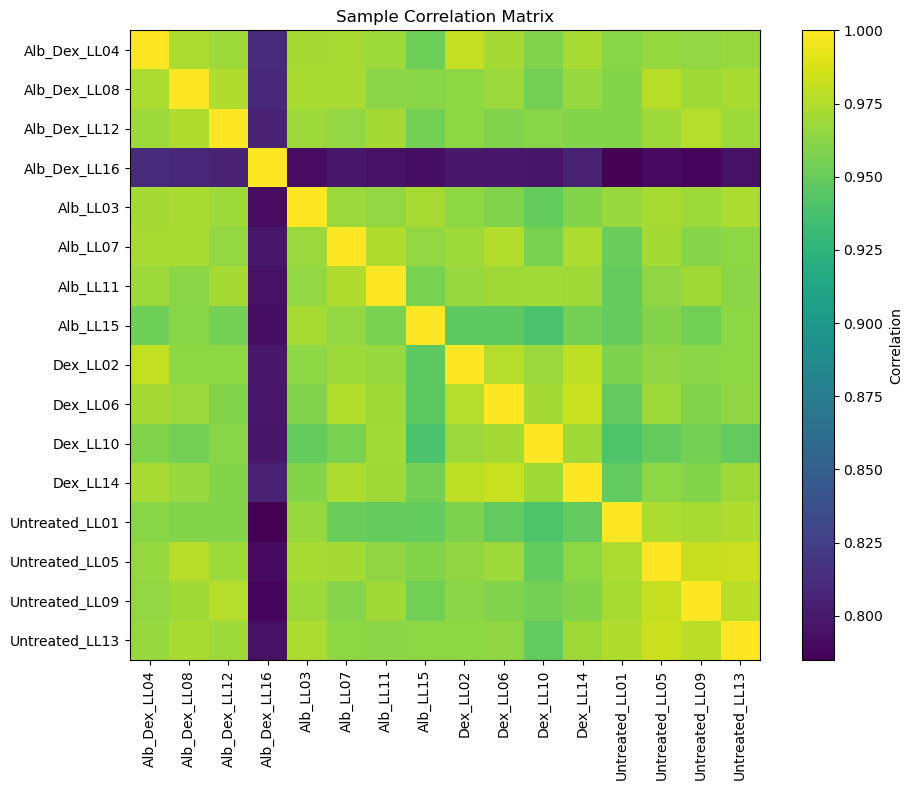

In [41]:
#Plot:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index)

plt.title("Sample Correlation Matrix")

plt.tight_layout()
plt.show()

In [42]:

#9. Identify highly variable genes
#Calculate variance across samples:

gene_variance = expr_matrix.var(axis=1)

top_hvg = gene_variance.sort_values(ascending=False).head(50)

print("Top 20 highly variable genes:")
print(top_hvg.head(20))

Top 20 highly variable genes:
Gene
SNORD29     39.977959
SNORD31     39.508847
MIR24-1     37.751372
FTL         36.262153
SNORD2      34.224553
SNORD27     32.592368
SNORD49A    31.154581
SNORD68     30.689455
MIR4461     29.726705
MIR631      29.323677
MIR374C     29.306062
SNORD45B    29.025144
IGFBP5      28.671976
SNORD55     27.698378
MIR3189     27.156142
SNORD38A    27.114483
QSOX1       26.807950
SNORD34     26.229669
MIR3191     25.331872
SNORD102    25.066494
dtype: float64


In [43]:

#10. Perform PCA

pca_input = expr_matrix.T
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_input)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"],index=pca_input.index)
pca_df = pca_df.reset_index()
pca_df = pca_df.rename( columns={"Sample_ID": "Sample_ID"})
print(pca_df.head())

      Sample_ID         PC1        PC2
0  Alb_Dex_LL04   -7.566850 -11.631405
1  Alb_Dex_LL08   -7.220959  11.154854
2  Alb_Dex_LL12   -8.842531   8.131765
3  Alb_Dex_LL16  190.847370   2.251091
4      Alb_LL03  -15.176607  25.926748


In [44]:

# To Add treatment information:
metadata = (expression_long[ ["Sample_ID", "Condition"]].drop_duplicates())

pca_df = pca_df.merge(metadata, on="Sample_ID")
display(pca_df)
# Keep only one Condition column
pca_df = pca_df.drop(columns=["Condition_x", "Condition_y"], errors="ignore")

# Check the columns
print(pca_df.columns)

,Sample_ID,PC1,PC2,Condition
0,Alb_Dex_LL04,-7.566850,-11.631405,Albuterol_Dexamethasone
1,Alb_Dex_LL08,-7.220959,11.154854,Albuterol_Dexamethasone
2,Alb_Dex_LL12,-8.842531,8.131765,Albuterol_Dexamethasone
3,Alb_Dex_LL16,190.847370,2.251091,Albuterol_Dexamethasone
4,Alb_LL03,-15.176607,25.926748,Albuterol
5,Alb_LL07,-14.130425,-13.805426,Albuterol
6,Alb_LL11,-15.920398,-21.133627,Albuterol
7,Alb_LL15,-11.329549,27.348578,Albuterol
8,Dex_LL02,-13.009244,-28.955174,Dexamethasone
9,Dex_LL06,-13.527981,-37.660332,Dexamethasone


Index(['Sample_ID', 'PC1', 'PC2', 'Condition'], dtype='object')


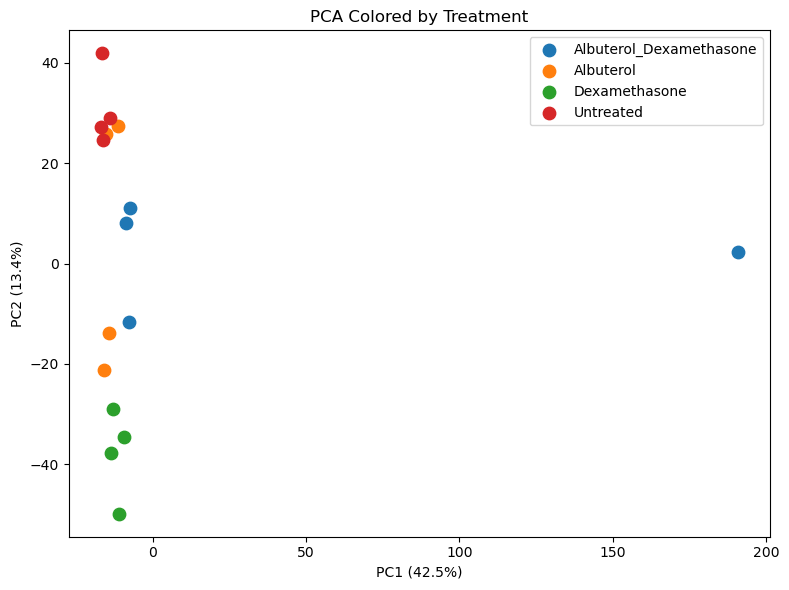

In [45]:
#11. Color PCA by treatment
plt.figure(figsize=(8, 6))

for condition in pca_df["Condition"].unique():

    subset = pca_df[pca_df["Condition"] == condition]

    plt.scatter(subset["PC1"],subset["PC2"],label=condition,s=80 )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")

plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")

plt.title("PCA Colored by Treatment")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:

# 12,Color PCA by batch/donor/sex if available.
#call s_metadata from Assignmet and check  batch are availavble
import pandas as pd

s_meta = pd.read_excel(r"C:\Users\user\project\results\tables\s_meta.xlsx")

print(s_meta)
print("Shape:", s_meta.shape)

         Sample_ID      GSM_ID                Treatment Cell_Line  \
0         Dex_LL14  GSM1275862                Untreated    N61311   
1         Dex_LL06  GSM1275863            Dexamethasone    N61311   
2         Dex_LL02  GSM1275864                Albuterol    N61311   
3         Dex_LL10  GSM1275865  Albuterol_Dexamethasone    N61311   
4         Alb_LL07  GSM1275866                Untreated   N052611   
5         Alb_LL03  GSM1275867            Dexamethasone   N052611   
6         Alb_LL11  GSM1275868                Albuterol   N052611   
7         Alb_LL15  GSM1275869  Albuterol_Dexamethasone   N052611   
8   Untreated_LL09  GSM1275870                Untreated   N080611   
9   Untreated_LL05  GSM1275871            Dexamethasone   N080611   
10  Untreated_LL13  GSM1275872                Albuterol   N080611   
11  Untreated_LL01  GSM1275873  Albuterol_Dexamethasone   N080611   
12    Alb_Dex_LL08  GSM1275874                Untreated   N061011   
13    Alb_Dex_LL04  GSM1275875    

In [ ]:
#from the above out put there is no  batch availavble"

Expected samples:
['Dex_LL14', 'Dex_LL06', 'Dex_LL02', 'Dex_LL10', 'Alb_LL07', 'Alb_LL03', 'Alb_LL11', 'Alb_LL15', 'Untreated_LL09', 'Untreated_LL05', 'Untreated_LL13', 'Untreated_LL01', 'Alb_Dex_LL08', 'Alb_Dex_LL04', 'Alb_Dex_LL12', 'Alb_Dex_LL16']

Expression DataFrame found: df
Number of matching samples: 16

Expression matrix shape:
(23273, 16)

Samples used:
['Dex_LL14', 'Dex_LL06', 'Dex_LL02', 'Dex_LL10', 'Alb_LL07', 'Alb_LL03', 'Alb_LL11', 'Alb_LL15', 'Untreated_LL09', 'Untreated_LL05', 'Untreated_LL13', 'Untreated_LL01', 'Alb_Dex_LL08', 'Alb_Dex_LL04', 'Alb_Dex_LL12', 'Alb_Dex_LL16']

After removing missing values:
(19653, 16)

PCA input shape (samples × genes):
(16, 19653)

PCA metadata:
     Sample_ID        PC1        PC2               Treatment Cell_Line   Donor
      Dex_LL14 -67.416802 -54.217343               Untreated    N61311  N61311
      Dex_LL06 -73.680284 -25.631043           Dexamethasone    N61311  N61311
      Dex_LL02 -57.419743 -18.498008               Albut

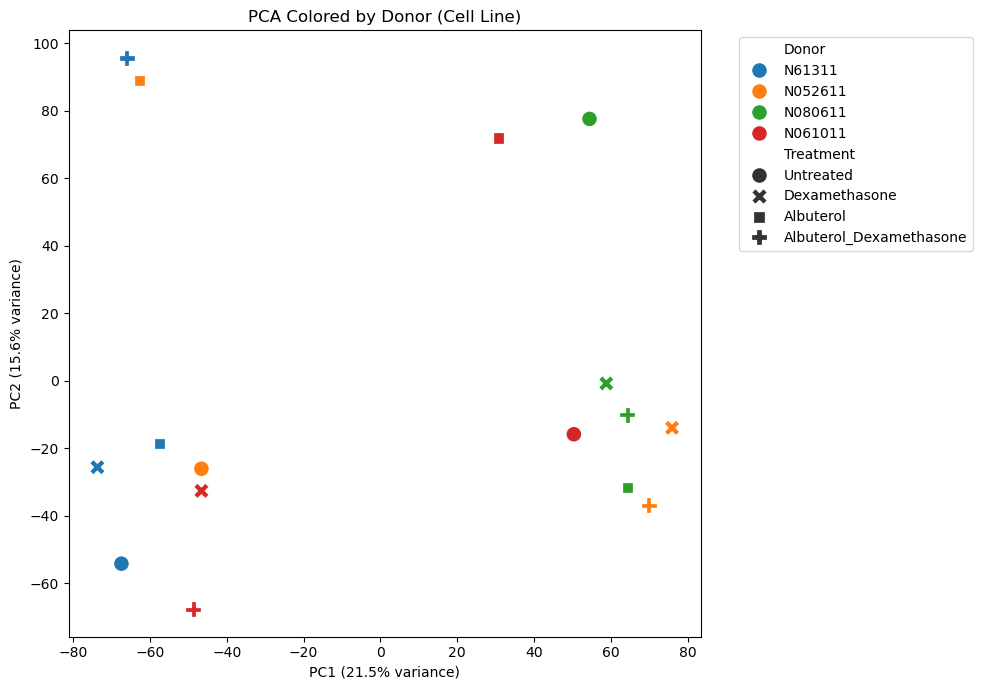

In [15]:

# AUTOMATIC PCA FROM EXISTING EXPRESSION DATAFRAME
# Color PCA by Donor / Cell_Line
# Shape = Treatment


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



# 1. Get sample IDs from metadata


sample_ids = s_meta["Sample_ID"].astype(str).tolist()

print("Expected samples:")
print(sample_ids)



# 2. Automatically find expression DataFrame


expression_df = None
expression_name = None
best_match_count = 0


# IMPORTANT: list() prevents RuntimeError:
# dictionary changed size during iteration
for name, value in list(globals().items()):

    if isinstance(value, pd.DataFrame):

        matching_samples = [
            sample for sample in sample_ids
            if sample in value.columns.astype(str).tolist() ]

        # Keep the DataFrame with the highest number
        # of matching sample columns
        if len(matching_samples) > best_match_count:

            best_match_count = len(matching_samples)
            expression_df = value.copy()
            expression_name = name

# 3. Check whether expression data was found

if expression_df is None or best_match_count == 0:

    print("ERROR: Expression DataFrame was not found.")

else:

    print("\nExpression DataFrame found:", expression_name)
    print("Number of matching samples:", best_match_count)


    # 4. Keep only sample columns


    available_samples = [
        sample for sample in sample_ids
        if sample in expression_df.columns.astype(str).tolist()]

    expr_pca = expression_df[available_samples].copy()

    print("\nExpression matrix shape:")
    print(expr_pca.shape)

    print("\nSamples used:")
    print(expr_pca.columns.tolist())
    
    # 5. Convert values to numeric
    
    expr_pca = expr_pca.apply(
        pd.to_numeric,
        errors="coerce" )

    # Remove genes with missing values
    expr_pca = expr_pca.dropna(axis=0)

    print("\nAfter removing missing values:")
    print(expr_pca.shape)

    # 6. Transpose: samples × genes
  
    X = expr_pca.T
    print("\nPCA input shape (samples × genes):")
    print(X.shape)

    # 7. Log2 transformation

    X_log = np.log2(X + 1)
   
    # 8. Standardize expression

    X_scaled = StandardScaler().fit_transform(X_log)

    # 9. Perform PCA

    pca = PCA(n_components=2)

    pca_result = pca.fit_transform(X_scaled)

    # 10. Create PCA dataframe

    pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"] )

    pca_df["Sample_ID"] = X.index
    # 11. Prepare metadata

    meta_for_pca = s_meta.copy()
    # Use Cell_Line as donor grouping
    meta_for_pca["Donor"] = meta_for_pca["Cell_Line"]

    # 12. Merge PCA with metadata

    pca_meta = pca_df.merge(meta_for_pca[[
                "Sample_ID",
                "GSM_ID",
                "Treatment",
                "Cell_Line",
                "Donor"] ],on="Sample_ID", how="left" )


    
    # 13. Check merged data

    print("\nPCA metadata:")
    print(
        pca_meta[ [
                "Sample_ID",
                "PC1",
                "PC2",
                "Treatment",
                "Cell_Line",
                "Donor" ]].to_string(index=False) )

    # 14. PCA Plot
    # Color = Donor
    # Shape = Treatment

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        data=pca_meta,
        x="PC1",
        y="PC2",
        hue="Donor",
        style="Treatment",
        s=130)

    plt.title("PCA Colored by Donor (Cell Line)")

    plt.xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)" )

    plt.ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left")

    plt.tight_layout()
    plt.show()

     Sample_ID               Treatment   Donor         PC1         PC2  Distance_from_center
  Alb_Dex_LL16 Albuterol_Dexamethasone N061011 -180.123215 -117.467184            215.041652
      Dex_LL10 Albuterol_Dexamethasone  N61311  -19.942170  101.790856            103.725930
      Alb_LL11               Albuterol N052611  -18.931028   97.035066             98.864492
      Alb_LL15 Albuterol_Dexamethasone N052611   46.776914  -66.756786             81.514098
      Alb_LL03           Dexamethasone N052611   69.325003  -41.958138             81.033582
Untreated_LL13               Albuterol N080611   43.433025  -60.732165             74.664741
Untreated_LL01 Albuterol_Dexamethasone N080611   59.984512  -33.790588             68.847262
Untreated_LL09               Untreated N080611   65.905497   13.121683             67.199056
      Dex_LL06           Dexamethasone  N61311  -52.414269   40.902244             66.484955
      Dex_LL14               Untreated  N61311  -65.169950    8.400925

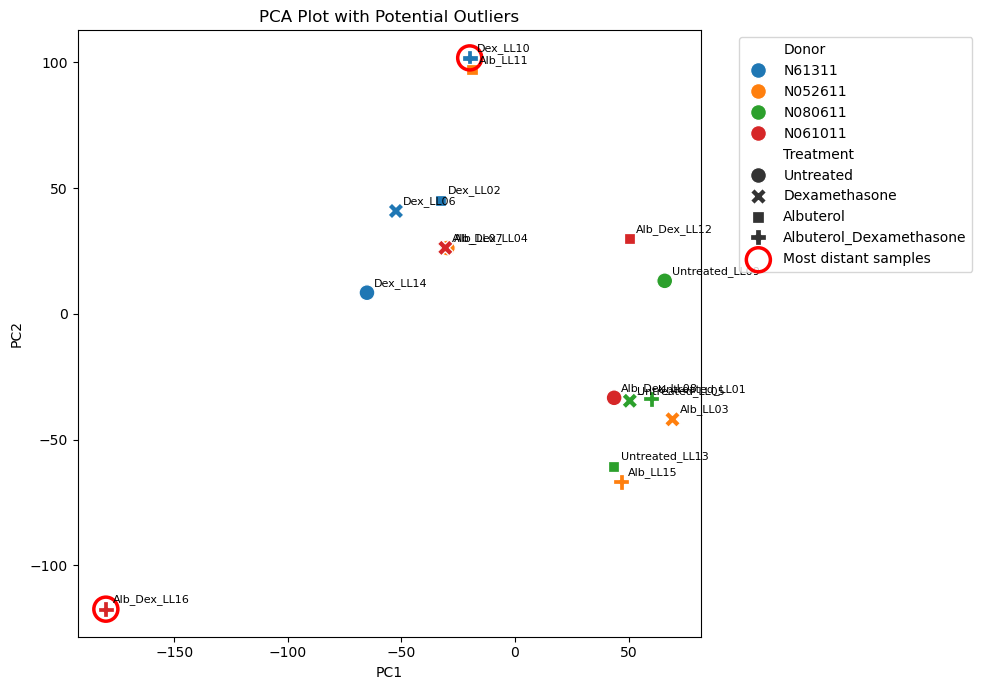

In [74]:
# 13. Investigate outliers

# An outlier is a sample that is unusually far from the other samples in the PCA plot or clustering analysis.
# Calculate distance of each sample from the PCA center
pca_meta["Distance_from_center"] = np.sqrt(
    pca_meta["PC1"]**2 + pca_meta["PC2"]**2)

# Sort samples from most distant to least distant
outliers = pca_meta.sort_values(
    "Distance_from_center",
    ascending=False)

print(outliers[["Sample_ID",
            "Treatment",
            "Donor",
            "PC1",
            "PC2",
            "Distance_from_center"]].to_string(index=False))

# Plot PCA with samples labeled by distance from center

plt.figure(figsize=(10, 7))

# Plot all samples
sns.scatterplot(
    data=pca_meta,
    x="PC1",
    y="PC2",
    hue="Donor",
    style="Treatment",
    s=130)

# Label every sample
for _, row in pca_meta.iterrows():
    plt.annotate(
        row["Sample_ID"],
        (row["PC1"], row["PC2"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8 )

# Highlight the 2 most distant samples
top_outliers = outliers.head(2)
plt.scatter(
    top_outliers["PC1"],
    top_outliers["PC2"],
    s=300,
    facecolors="none",
    edgecolors="red",
    linewidths=2.5,
    label="Most distant samples")

plt.title("PCA Plot with Potential Outliers")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
# 14 Summarize biological and technical findings

Biologically, the RNA-seq dataset from GSE52778 captures transcriptional responses to four treatment conditions: 
    1, untreated, 
    2, albuterol,
    3, dexamethasone, and 
    4, combined albuterol–dexamethasone. 
        
The data comprise 372,368 gene–sample measurements, and exploratory log-transformation of FPKM values was performed to stabilize variance 
for visualization. The primary biological signal is treatment-associated: PCA shows that dexamethasone, albuterol, and combined treatments 
each induce distinct global expression patterns relative to untreated samples, consistent with drug-driven remodeling of the transcriptome.

Technically, The analysis uses FPKM rather than raw counts, which limits compatibility with state-of-the-art count-based differential-expression 
frameworks. One combined-treatment sample (Alb_Dex_LL16) displays an extreme PC1 value (~190.85), indicating a likely outlier or normalization 
artifact that could distort downstream results. Additionally, the notebook presents only exploratory summaries—no formal differential-expression 
testing, multiple-testing correction, or pathway-level interpretation has yet been conducted, and the small number of replicates per condition can
reduces statistical power.

# 15,State what statistical analysis should be performed next

The next analysis should be a formal, gene-wise differential-expression test across the four treatment groups, using an appropriate model for 
RNA-seq data and using raw counts use other tools such as DESeq2, should be applied after filtering lowly expressed genes and performing 
library-size normalization; if only FPKM values exist,  transformed and normalized expression can be used with clear caveats. The primary 
hypothesis for each gene is equality of mean expression across the four conditions, which can be tested within a unified
linear or generalized linear model framework.

